In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
raw_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\torch.csv',sep=',')
raw_data_c=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\torch_columns.csv',sep=',')
raw_data_c.info()

<class 'pandas.DataFrame'>
RangeIndex: 7922 entries, 0 to 7921
Columns: 400 entries, Message to Unnamed: 399
dtypes: str(400)
memory usage: 24.2 MB


C:\Users\Jose.Hurtado\AppData\Local\Temp\ipykernel_16124\3342976490.py:2: DtypeWarning: Columns (0: Unnamed: 29, 1: Unnamed: 30, 2: Unnamed: 31, 3: Unnamed: 32, 4: Unnamed: 33, 5: Unnamed: 34, 6: Unnamed: 35, 7: Unnamed: 36, 8: Unnamed: 37, 9: Unnamed: 38, 10: Unnamed: 39, 11: Unnamed: 40, 12: Unnamed: 41, 13: Unnamed: 42, 14: Unnamed: 43, 15: Unnamed: 44, 16: Unnamed: 45, 17: Unnamed: 46, 18: Unnamed: 47, 19: Unnamed: 48, 20: Unnamed: 49, 21: Unnamed: 50, 22: Unnamed: 51, 23: Unnamed: 52, 24: Unnamed: 53, 25: Unnamed: 54, 26: Unnamed: 55, 27: Unnamed: 56, 28: Unnamed: 57, 29: Unnamed: 58, 30: Unnamed: 59, 31: Unnamed: 60, 32: Unnamed: 61, 33: Unnamed: 62, 34: Unnamed: 63, 35: Unnamed: 64, 36: Unnamed: 65, 37: Unnamed: 66, 38: Unnamed: 67, 39: Unnamed: 68, 40: Unnamed: 69, 41: Unnamed: 70, 42: Unnamed: 71, 43: Unnamed: 72, 44: Unnamed: 73, 45: Unnamed: 74, 46: Unnamed: 75, 47: Unnamed: 76, 48: Unnamed: 77, 49: Unnamed: 78, 50: Unnamed: 79, 51: Unnamed: 80, 52: Unnamed: 81, 53: Unnamed:

In [17]:
raw_data_codes=[]

for i in range(0,raw_data.shape[0]):
    raw_data_codes.append(raw_data.iloc[i,2][6:8])

raw_data['Codes']=raw_data_codes
raw_data['Codes'].value_counts()

Codes
02    5396
03    2083
09     250
04     177
01      13
11       3
Name: count, dtype: int64

In [18]:
torch_codes_02=raw_data[raw_data['Codes'].str.contains('02')]
torch_codes_04=raw_data[raw_data['Codes'].str.contains('04')]
torch_codes_0204=pd.concat([torch_codes_02,torch_codes_04])
torch_codes_0204.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\torch_analysis.csv',sep=',')

ignition_on_interval=[]
ignition_off_interval=[]
io=[]
odometer=[]
date=[]
ext_ps=[]
speed=[]
#over_speed=[]
gnss=[]
#a_code=[]
#direction=[]
accum_fuel_consumption=[]
#instant_fuel_consumption=[]
#rpm=[]
cool_temp=[]
#air_in_flow_temp=[]
remain_fuel_rate=[]

for i in range(0,torch_codes_0204.shape[0]):
    ignition_on_interval.append(int(torch_codes_0204.iloc[i,2][32:36],16))
    ignition_off_interval.append(int(torch_codes_0204.iloc[i,2][36:40],16))
    io.append(bin(int(torch_codes_0204.iloc[i,2][64:68],16)))
    odometer.append(int(torch_codes_0204.iloc[i,2][72:80],16))
    date.append(torch_codes_0204.iloc[i,2][82:96])
    ext_ps.append((float(int(torch_codes_0204.iloc[i,2][126:130])))/100)
    speed.append(int(torch_codes_0204.iloc[i,2][130:134],16))    
    #over_speed.append(torch_codes_0204.iloc[i,2])
    gnss.append(int(torch_codes_0204.iloc[i,2][51:52],16))
    #a_code.append(torch_codes_0204.iloc[])
    #direction.append(torch_codes_0204.iloc[i,2])
    accum_fuel_consumption.append(float(int(torch_codes_0204.iloc[i,2][134:142],16))/1000)
    #instant_fuel_consumption.append(torch_codes_0204.iloc[i,2]) invalid!
    #rpm.append(torch_codes_0204.iloc[i,2]) invalid!
    cool_temp.append(int(torch_codes_0204.iloc[i,2][158:160],16))
    #air_in_flow_temp.append(torch_codes_0204.iloc[i,2])
    remain_fuel_rate.append(torch_codes_0204.iloc[i,2][166:168])

torch_codes_0204['i_on']=ignition_on_interval
torch_codes_0204['i_off']=ignition_off_interval
torch_codes_0204['io']=io
torch_codes_0204['odometer']=odometer
torch_codes_0204['date']=date
torch_codes_0204['ext_ps']=ext_ps
torch_codes_0204['speed']=speed
torch_codes_0204['gnss']=gnss
torch_codes_0204['acc_fuel_c']=accum_fuel_consumption
torch_codes_0204['cool_temp']=cool_temp
torch_codes_0204['remain_fuel %']=remain_fuel_rate

print(torch_codes_0204[['i_on','i_off','io','odometer','date','ext_ps','speed','acc_fuel_c','remain_fuel %','gnss','cool_temp']])

      i_on  i_off                  io  odometer            date  ext_ps  \
0       25    300  0b1000000000000000      4402  26052119081582    0.49   
7       25    300  0b1000000000000000      4402  26052119081582    0.49   
10      25    300  0b1000000000000000         0  260521142204CD    4.98   
12      25    300  0b1000000000000000      4402  26052119081582    0.49   
13      25    300  0b1000000000000000      4402  26052119081582    0.49   
...    ...    ...                 ...       ...             ...     ...   
7453    25    300                 0b0  86669592  2606010220519A   12.84   
7456    25    300   0b100000000000000  86669592  2606010228169A   13.97   
7482    25    300                 0b0  86670667  260601023528CD   12.85   
7488    25    300   0b100000000000000  86670673  26060102502200   14.42   
7511    25    300                 0b0  86671012  26060102574966   12.95   

      speed   acc_fuel_c remain_fuel %  gnss  cool_temp  
0         0  4294967.295            FF   

[0, 0, 0, 0, 0, 136, 136, 135, 137, 137, 138, 136, 137, 135, 136, 135, 135, 135, 135, 134, 134, 134, 136, 136, 136, 136, 136, 136, 136, 136, 136, 136, 136, 135, 134, 135, 135, 135, 134, 134, 134, 134, 146, 146, 146, 146, 144, 144, 144, 144, 146, 146, 146, 146, 146, 146, 146, 145, 146, 146, 146, 146, 146, 146, 146, 143, 143, 145, 144, 145, 143, 143, 143, 144, 143, 143, 142, 143, 143, 143, 143, 143, 145, 145, 145, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 144, 143, 143, 146, 143, 142, 145, 140, 140, 140, 141, 141, 141, 142, 142, 139, 141, 141, 141, 141, 141, 140, 141, 140, 138, 140, 141, 139, 139, 139, 139, 139, 139, 139, 140, 138, 139, 139, 139, 139, 138, 139, 139, 139, 139, 139, 139, 139, 139, 140, 137, 140, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139, 139,

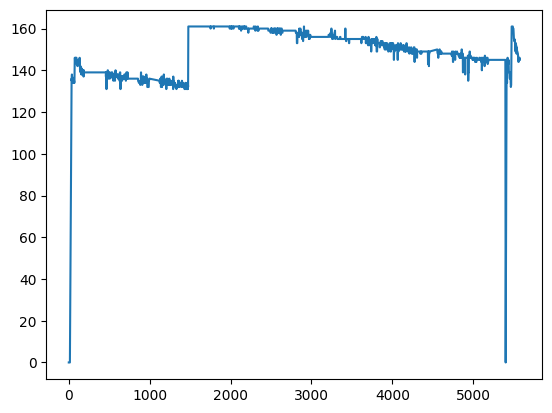

In [19]:
fuel_data=[]
x_axis=[]
#torch_codes_0204.info()

for i in range(0,torch_codes_0204.shape[0]):
    if torch_codes_0204.iloc[i,14]!='FF':
        fuel_data.append(int(torch_codes_0204.iloc[i,14],16))
        x_axis.append(i)
print(fuel_data)

plt.plot(x_axis,fuel_data)

Historical locations

In [20]:
hl=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\historicallocations.xlsx')
hl.info()

<class 'pandas.DataFrame'>
RangeIndex: 2890 entries, 0 to 2889
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Secuencia       2890 non-null   int64  
 1   Unidad          2890 non-null   str    
 2   Eventos         2890 non-null   str    
 3   Fecha           2890 non-null   str    
 4   Pt. Referencia  693 non-null    str    
 5   Dirección       2890 non-null   str    
 6   Velocidad       2890 non-null   int64  
 7   Temperatura     0 non-null      float64
 8   Conductor       0 non-null      float64
 9   Latitud         2890 non-null   float64
 10  Longitud        2890 non-null   float64
dtypes: float64(4), int64(2), str(5)
memory usage: 248.5 KB


In [21]:
hl['Eventos'].value_counts()

Eventos
Conduciendo             1051
Estacionado             1019
Inmóvil - Detenido       632
Saliendo de Landmark      63
Entrando a Landmark       62
Ignición Encendida        32
Ignición Apagada          31
Name: count, dtype: int64